## Galaxy and quasar 2

Define the needed functions. Load the data and scale the features even though in this case values of magnitude are quite similare

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, precision_score
from sklearn.model_selection import train_test_split, GridSearchCV
from astroML.utils import completeness_contamination
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from matplotlib import pyplot as plt
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.metrics import log_loss
#%%
# def geterror(y_true,y_pred):
#     completeness, contamination = completeness_contamination(y_pred, y_true)
#     return contamination
#     # return np.sqrt( np.sum(( y_true - y_pred )**2) / len(y_true) )
# scorer = make_scorer(geterror, greater_is_better=False)
scorer = 'neg_log_loss'
#%%
def CrossVal(clf,param_grid):
    grid = GridSearchCV(clf, param_grid,scoring= scorer, cv=5, return_train_score = True, n_jobs = -1)
    grid.fit(X_train, y_train)
    print(f'The best is {grid.best_params_}')
    return grid.best_estimator_

#%%
def Quantify(mlp):
    y_prob_train = mlp.predict_proba(X_train)[:,1]
    y_pred_train = mlp.predict(X_train)
    y_prob = mlp.predict_proba(X_test)[:,1]
    y_pred = mlp.predict(X_test)
    
    
    loss = log_loss(y_test, y_prob)
    print(f"Log Loss on test set: {loss:.4f}")
    loss = log_loss(y_train, y_prob_train)
    print(f"Log Loss on training set: {loss:.4f}")
        
    
    disp = ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train, display_labels=classes)
    disp.ax_.set_title("Confusion Matrix (Training Set)")
    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=classes)
    disp.ax_.set_title("Confusion Matrix (Test Set)")
    
    
    print("Accuracy on training set:", accuracy_score(y_train, y_pred_train))
    print("Accuracy on test set:", accuracy_score(y_test, y_pred))
    
    # print("Classification Report:\n", classification_report(y_test, y_pred,target_names=classes))
    
    completeness, contamination = completeness_contamination(y_pred, y_test)
    print("completeness", completeness)
    print("contamination", contamination)
    # precision, recall, thresh2 = precision_recall_curve(ytest, y_prob)
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    
    # add (0, 0) as first point
    fpr = np.concatenate([[0], fpr])
    tpr = np.concatenate([[0], tpr])
    # Here we add (1,0) 
    # precision = np.concatenate([[0], precision])
    # recall = np.concatenate([[1], recall])
    # thresh2 = np.concatenate([[0], thresh2])
    # RocCurveDisplay.from_predictions(y_test, y_prob, name="MLP")
    # plt.title("ROC Curve")
    # plt.show()
    plt.figure()
    ax1 = plt.subplot(111)
    ax1.plot(fpr, tpr)
    ax1.set_xlim(0, 0.05)
    ax1.set_ylim(0.8, 1.02)
    ax1.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax1.set_xlabel('false positive rate')
    ax1.set_ylabel('true positive rate')

    
df = pd.read_csv('galaxyquasar.csv')
le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['class'])
df['u-g'] = df['u'] - df['g']
df['g-r'] = df['g'] - df['r']
df['r-i'] = df['r'] - df['i']
df['i-z'] = df['i'] - df['z']
classes= le.classes_

feature_names = df.columns[-4:]
X = df[feature_names].to_numpy()
y = df['class_encoded'].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_feature_names = ['s_' + name for name in feature_names]

# Add the scaled features to the DataFrame
for i, col in enumerate(scaled_feature_names):
    df[col] = X_scaled[:, i]
    
    
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,random_state=1)

Do a quick deep learning exploration with MPL. Performances are quite high with a "random" exploration and similar to the values obtained is galaxyquasar1

Log Loss on test set: 0.0449
Log Loss on training set: 0.0451
Accuracy on training set: 0.98688
Accuracy on test set: 0.98672
completeness 0.9608167770419426
contamination 0.051742919389978215


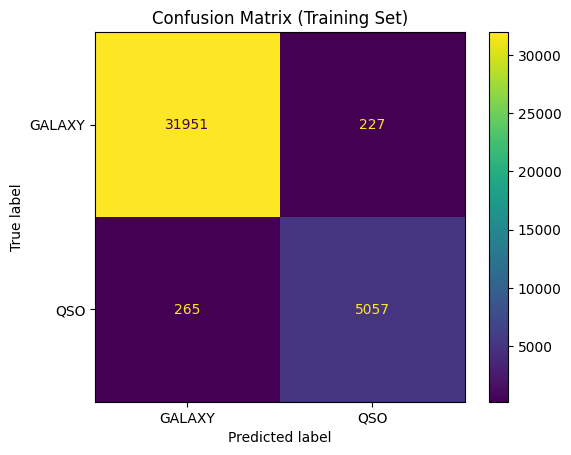

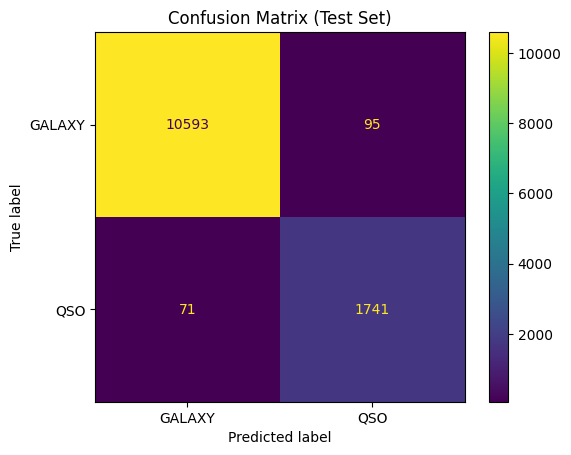

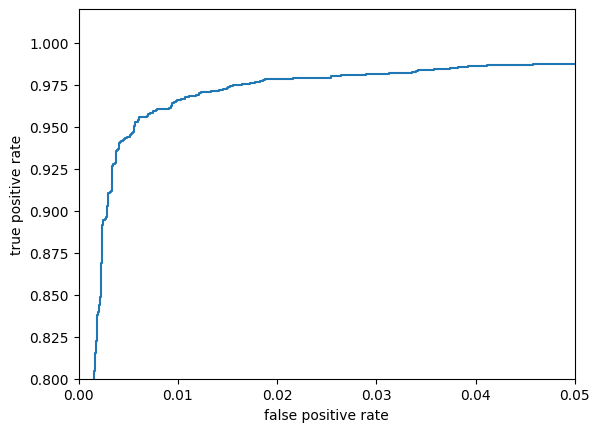

In [3]:
#%%
mlp = MLPClassifier(
    hidden_layer_sizes=(50, 30),  # Two hidden layers: 50 and 30 neurons
    activation='relu',            # Activation function
    solver='adam',                # Optimizer
    max_iter=200,                 # Maximum number of iterations
    random_state=42
)
#%%
mlp.fit(X_train, y_train)
#%%
Quantify(mlp)

Cross validate few params

The best is {'activation': 'logistic', 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.01}
Log Loss on test set: 0.0441
Log Loss on training set: 0.0457
Accuracy on training set: 0.98696
Accuracy on test set: 0.9872
completeness 0.9530905077262694
contamination 0.041620421753607105


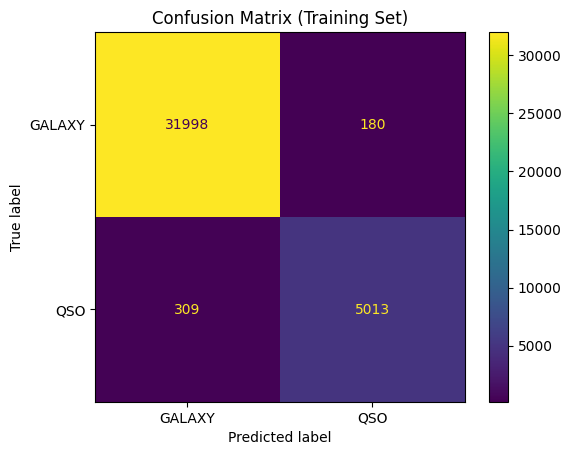

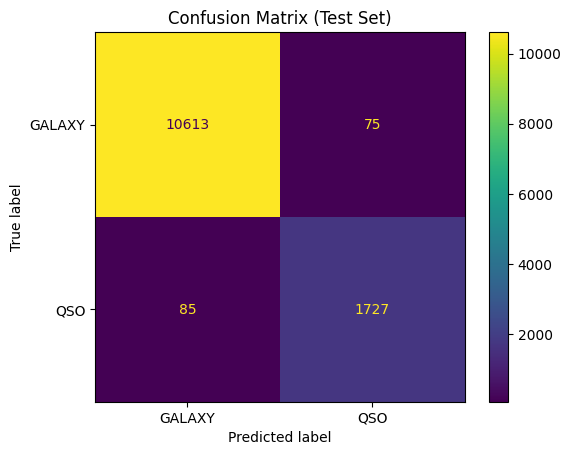

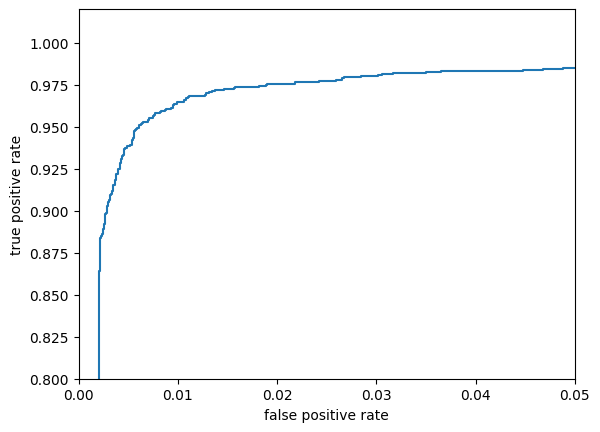

In [5]:
param_grid = {
    'hidden_layer_sizes': [(10,5), (32,16), (32,32,32)],
    'activation': ['relu', 'logistic'],
    'learning_rate_init': [0.001, 0.01]
}

mlp = MLPClassifier(max_iter=200, random_state=42)
mlp = CrossVal(mlp,param_grid)
Quantify(mlp)